<a href="https://colab.research.google.com/github/sanchi23002/COMPUTER_VISION_WITH_OPENCV_AND_DEEP_LEARNING/blob/main/NN_WITH_CUSTOM_IMAGE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

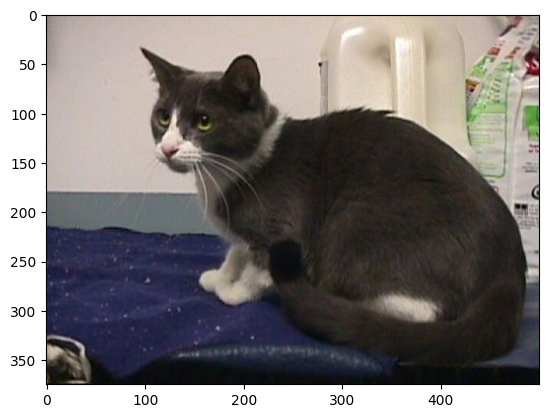

In [3]:
cat4 = cv2.imread('4.jpg')
cat4 = cv2.cvtColor(cat4, cv2.COLOR_BGR2RGB)
plt.imshow(cat4)

In [4]:
cat4.shape

(375, 500, 3)

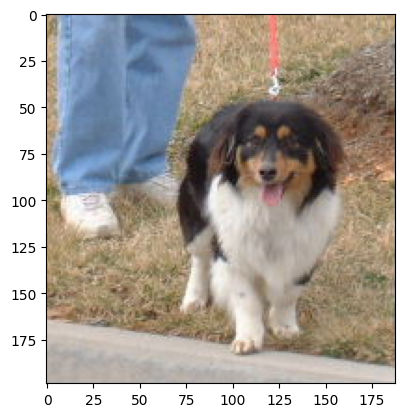

In [5]:
dog = cv2.imread('2.jpg')
dog = cv2.cvtColor(dog, cv2.COLOR_BGR2RGB)
plt.imshow(dog)

In [6]:
print(dog.shape)
print(dog.max())

(199, 188, 3)
255


In [7]:
import tensorflow as tf

# ✅ Correct import for image_dataset_from_directory
from tensorflow.keras.utils import image_dataset_from_directory

# ✅ Correct way to do augmentation in modern TF (no ImageDataGenerator needed)
from tensorflow.keras import layers


In [8]:
## this is cell is doing the same work as the upper one is doing but no orange mark is here
##import tensorflow as tf

# These two lines suppress the squiggly warnings
##image_dataset_from_directory = tf.keras.utils.image_dataset_from_directory

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
image_gen = ImageDataGenerator(rotation_range=30, width_shift_range= 0.1,
                               height_shift_range = 0.1, rescale = 1/255,
                               shear_range = 0.2,zoom_range = 0.2,
                               horizontal_flip = True, fill_mode = 'nearest')

rotation_range=30
geometric


Randomly rotates the image by a value sampled uniformly from [-30°, +30°] on each training step.


width_shift_range=0.1
geometric


Shifts the image horizontally by up to 10% of the total width, randomly left or right.

rescale=1/255
normalisation


Multiplies every pixel value by 1/255 ≈ 0.00392, mapping pixel range from [0, 255] to [0.0, 1.0].

shear_range=0.2
geometric


Applies a shear transformation — slants the image along one axis by up to 0.2 radians (~11.5°).

zoom_range=0.2
geometric


Randomly zooms in or out by up to 20%. A value of 0.2 means the zoom factor is sampled from [0.8, 1.2].

horizontal_flip=True
flip


Randomly mirrors the image left-to-right with 50% probability on each sample.

fill_mode='nearest'
fill


After a geometric transform creates empty border pixels, fills them by repeating the nearest edge pixel value.

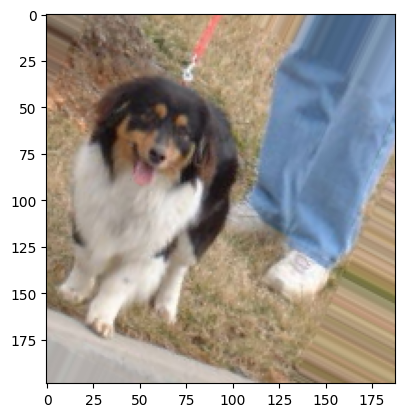

In [11]:
plt.imshow(image_gen.random_transform(dog))## every time you run this you will get diff random image

1. Where are the augmented images stored?


Nowhere. They are never saved to your hard drive, and they don't take up any disk space.

Instead, the images are augmented in-memory (RAM) on the fly, right before they are handed to your GPU for training.

flow_from_directory grabs a batch of original images (e.g., 32 images) from your folder.

image_gen applies random transformations (like a 15-degree rotation or a horizontal flip) to those 32 images in your RAM.

The modified batch is immediately passed to the neural network to calculate gradients.

As soon as that training step finishes, that batch is completely discarded from RAM to make room for the next batch.

:::::Every single time an epoch runs, the model looks at your dataset. But because the transformations are randomized, the model almost never sees the exact same image twice.

In [12]:
# Cell 1 — mount drive
from google.colab import drive
drive.mount('/content/drive')

# Cell 2 — extract zip
!unzip -q /content/drive/MyDrive/cat_dog/CATS_DOGS.zip -d /content/CATS_DOGS

# Cell 3 — check structure
import os
for root, dirs, files in os.walk('/content/CATS_DOGS'):
    level = root.replace('/content/CATS_DOGS', '').count(os.sep)
    if level <= 2:
        print('  ' * level + os.path.basename(root) + '/')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CATS_DOGS/
  CATS_DOGS/
    test/
    train/


In [13]:
import os
os.chdir('/content')

In [14]:
train_dataset = image_gen.flow_from_directory('CATS_DOGS/CATS_DOGS/train')

Found 18743 images belonging to 2 classes.


In [15]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [16]:
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters = 64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters = 128, kernel_size=(3,3), activation = 'relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters = 128, kernel_size=(3,3), activation = 'relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(units = 512, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(units =1, activation = 'sigmoid'))

model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
batch_size = 32
train_image_gen = image_gen.flow_from_directory('CATS_DOGS/CATS_DOGS/train', target_size=(150,150), batch_size=batch_size, class_mode = 'binary')

Found 18743 images belonging to 2 classes.


. The Image Data Generator Flow

This line sets up an automated pipeline to stream images straight out of a folder on your computer into your model during training. This is incredibly helpful because loading 18,000+ images into Python's RAM all at once would crash your computer.

train_image_gen =: Saves this entire streaming pipeline configuration into a variable that you will pass directly inside your model.fit() block later.

target_size=input_shape[:2]: Images on your computer come in all shapes and sizes, but your neural network requires a perfectly uniform input grid. This snippet grabs the height and width from your model configuration (e.g., (150, 150)) and automatically resizes every single image down to those exact dimensions on-the-fly as it reads them.

class_mode='binary': Tells the generator how to structure your target outputs. Because you are doing a classic binary task (Cat vs. Dog), it will automatically encode the images as simple 0s and 1s.

Note: If you were doing your multiclass digits problem here instead, you would change this configuration to class_mode='categorical'.

Imagine you are running a factory that makes custom picture frames, and your machine is built to only hold photos that are exactly 150 cm wide by 150 cm tall.

If people send you photos of all different shapes—some long and skinny, some massive squares, some tiny rectangles—your machine will jam.

To fix this, you hire an assistant to stand at the conveyor belt. Every time a weirdly shaped photo comes in, your assistant instantly crops or stretches it so it becomes exactly 150x150 before feeding it into the machine.

In [20]:
train_image_gen.class_indices

{'CAT': 0, 'DOG': 1}

In [22]:
test_image_gen = image_gen.flow_from_directory('CATS_DOGS/CATS_DOGS/test', target_size = (150,150), batch_size = batch_size, class_mode = 'binary')

Found 6251 images belonging to 2 classes.


In [23]:
## using all image properly

steps_per_epoch = train_image_gen.n // batch_size
validation_steps = test_image_gen.n// batch_size

In [24]:
result = model.fit(train_image_gen, epochs=5,steps_per_epoch=steps_per_epoch)

Epoch 1/5
 73/585 ━━━━━━━━━━━━━━━━━━━━ 1:55 226ms/step - accuracy: 0.5069 - loss: 0.7005

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


585/585 ━━━━━━━━━━━━━━━━━━━━ 146s 238ms/step - accuracy: 0.6147 - loss: 0.6464
Epoch 2/5
585/585 ━━━━━━━━━━━━━━━━━━━━ 0s 22us/step - accuracy: 0.6250 - loss: 0.6264   
Epoch 3/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


585/585 ━━━━━━━━━━━━━━━━━━━━ 191s 228ms/step - accuracy: 0.7113 - loss: 0.5611
Epoch 4/5
585/585 ━━━━━━━━━━━━━━━━━━━━ 0s 22us/step - accuracy: 0.6875 - loss: 0.5381   
Epoch 5/5
585/585 ━━━━━━━━━━━━━━━━━━━━ 131s 223ms/step - accuracy: 0.7465 - loss: 0.5112


585/585


Steps completed / total steps this epoch. 585 batches of 32 images each = all 18,743 images processed.

146s

Total wall-clock time this epoch took. 146 seconds ≈ 2.4 minutes.

238ms/step

Average time per batch (32 images). 238 milliseconds × 585 steps = ~139s. This is your GPU speed.

accuracy: 0.6147

61.47% of training images were correctly classified during this epoch. Higher = better.

loss: 0.6464

Binary cross-entropy loss. Measures how wrong the model is. Lower = better. Should decrease each epoch.

Why epoch 2 and 4 show "0s 22us/step"

Keras cached the data pipeline from epoch 1 into memory. Epochs 2 and 4 ran from cache — no disk read needed — so they completed almost instantly (microseconds per step). This is why they show 0s instead of ~146s. It is NOT an error.

UserWarning: "Your input ran out of data"

Your generator ran out of images before completing all 585 steps in epoch 3. This happens because ImageDataGenerator shuffles differently each epoch and sometimes exhausts the dataset slightly early. Keras interrupted and moved to the next epoch automatically. It only happened in odd epochs (1, 3, 5) — the non-cached ones.

In [25]:
result.history['accuracy']##[1st epoch, 2nd epoch, 3rd epoch, 4th epoch, 5th epoch]

[0.614665150642395, 0.625, 0.7113462686538696, 0.6875, 0.7464593052864075]

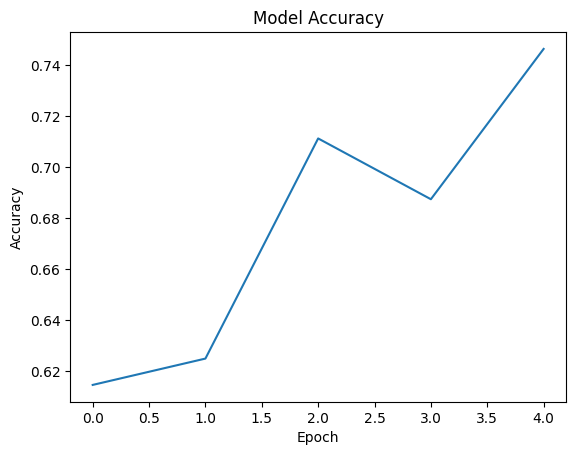

In [26]:
import matplotlib.pyplot as plt

plt.plot(result.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [27]:
from keras.models import load_model

In [ ]:
# model.save('cat_dog_100epochs.keras')

In [ ]:
import numpy as np
from keras.preprocessing import image

dog_file = '../DATA/CATS_DOGS/train/Dog/2.jpg'

dog_img = image.load_img(dog_file, target_size=(150, 150))

dog_img = image.img_to_array(dog_img)

dog_img = np.expand_dims(dog_img, axis=0)
dog_img = dog_img/255

In [ ]:
prediction_prob = model.predict(dog_img)

In [ ]:
# Output prediction
print(f'Probability that image is a dog is: {prediction_prob} ')

Probability that image is a dog is: [[0.97995687]] 
